### Load core data/ML libs, plotting tools, and sklearn utilities. We also silence warnings for a cleaner read.

In [1]:
# Libraries to help with reading and manipulating data
import pandas as pd
import numpy as np

# libaries to help with data visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Library to split data
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold

# To build model for prediction
from sklearn.tree import DecisionTreeClassifier
from sklearn import tree
from sklearn.preprocessing import LabelEncoder

# To get diferent metric scores
from sklearn.metrics import (f1_score,accuracy_score,recall_score,precision_score,confusion_matrix,)

# To ignore unnecessary warnings
import warnings
warnings.filterwarnings("ignore")

### Read the Excel file and display the head. 

In [2]:
# Oils dataset
oils_path = r"Oils.csv"
df_oils = pd.read_csv(oils_path).drop(columns=['Unnamed: 0'])

# --- FIX vs original notebook (for consistency with the other fixed notebooks) ---
# This notebook never reversed its spectral columns, and the source file here
# is already ascending by wavenumber, so this step is a no-op on this data -
# it's kept only so column order is explicitly guaranteed (matches
# raman_analysis/data_loading.py::get_spectral_columns in Paper3_code)
# rather than silently relying on the source file's incidental order.
def _is_wavenumber(col):
    try:
        float(col)
        return True
    except ValueError:
        return False

meta_cols = [c for c in df_oils.columns if not _is_wavenumber(c)]
spectral_cols = sorted([c for c in df_oils.columns if _is_wavenumber(c)], key=float)
df_oils = df_oils[meta_cols + spectral_cols]
display(df_oils.head())

,Oil_Type,Oil,500.8563,501.8205,502.7847,503.749,504.7132,505.6774,506.6417,507.6059,...,2990.507,2991.472,2992.436,2993.4,2994.364,2995.329,2996.293,2997.257,2998.221,2999.186
0,SO 0,SO,-0.458101,-1.495276,-1.862568,-1.831711,-1.535953,-0.993022,-0.391103,0.233167,...,0.322414,0.412911,0.510324,0.615980,0.714031,0.843851,0.954011,1.039072,1.095093,1.117694
1,SO 0,SO,0.068097,-0.399315,-0.678853,-0.814568,-0.855950,-0.791816,-0.674305,-0.513736,...,0.455966,0.500148,0.580671,0.709734,0.841224,0.943207,1.009186,1.037642,1.027740,0.978225
2,SO 0,SO,0.167223,-1.133351,-1.652558,-1.617278,-1.226656,-0.573671,0.003154,0.458940,...,0.567724,0.764727,0.917556,0.995929,1.028447,1.063251,1.095276,1.128665,1.164110,1.198602
3,SO 0,SO,-0.271799,-0.583166,-0.724528,-0.798817,-0.848749,-0.863939,-0.920526,-1.022233,...,0.305283,0.384108,0.568860,0.766478,0.917478,1.028797,1.115378,1.180302,1.224556,1.246197
4,SO 0,SO,-0.194513,-0.940731,-1.160886,-1.062074,-0.771085,-0.351588,-0.068750,0.085753,...,0.686066,0.809774,0.949498,1.038355,1.068043,1.113757,1.151863,1.185146,1.213659,1.234257


This spectrum is already baseline-corrected, smoothed, and Z-score normalized upstream (each wavenumber column centered and scaled across the dataset - see the source filename). A Z-score's negative values are a normal, physically meaningful part of that normalization (intensity below that column's own mean), not an instrument artifact like dark current - so unlike a raw intensity trace, there is no principled "zero" to shift this data to. We only report where the dataset's minimum sits, without altering the data.

In [3]:
# Spectral data starts from column 2
spectra = df_oils.iloc[:, 2:]

# Most negative value in the entire spectral dataset
min_value = spectra.min().min()

# Find row and column containing the minimum value
row_idx, col_idx = (spectra == min_value).stack().idxmax()

print("Most negative value:", min_value)
print("Most negative value:", min_value)
print("Row index:", row_idx)
print("Wavenumber:", col_idx)
print("Shift skipped (data is already Z-score normalized; negative values are physically meaningful)")
print("Minimum stays:", df_oils.iloc[:, 2:].min().min())

Most negative value: -7.583057172006416
Most negative value: -7.583057172006416
Row index: 622
Wavenumber: 1337.811
Shift skipped (data is already Z-score normalized; negative values are physically meaningful)
Minimum stays: -7.583057172006416


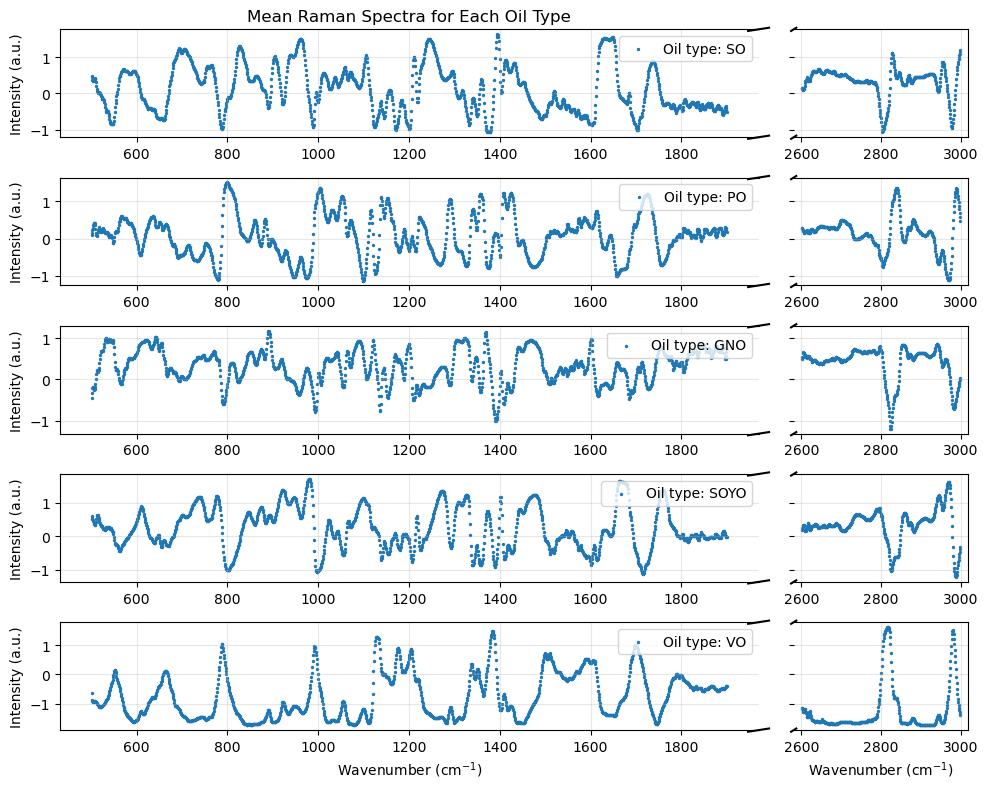

In [4]:
# Raman shifts
wavenumbers = df_oils.columns[2:].astype(float)

# Regions to keep
mask_left = wavenumbers <= 1900
mask_right = wavenumbers >= 2600

oils = df_oils['Oil'].unique()

fig, axes = plt.subplots(len(oils), 2, figsize=(10, 8), sharey='row', gridspec_kw={"width_ratios":[4,1]})

for idx, oil in enumerate(oils):
    subset = (df_oils[df_oils['Oil'] == oil].iloc[:, 2:].mean(axis=0))
    y = subset.values
    # LEFT SIDE
    axes[idx,0].scatter(wavenumbers[mask_left],y[mask_left],s=2,label=f"Oil type: {oil}")

    # RIGHT SIDE
    axes[idx,1].scatter(wavenumbers[mask_right],y[mask_right],s=2)
    axes[idx,0].set_ylabel("Intensity (a.u.)")
    axes[idx,0].legend(loc="upper right")
    axes[idx,0].grid(alpha=0.3)
    axes[idx,1].grid(alpha=0.3)

    # Remove touching borders
    axes[idx,0].spines['right'].set_visible(False)
    axes[idx,1].spines['left'].set_visible(False)
    axes[idx,1].tick_params(labelleft=False)

    # Broken-axis marks
    d = 0.015
    kwargs = dict(transform=axes[idx,0].transAxes,color='k',clip_on=False)

    axes[idx,0].plot((1-d,1+d),(-d,+d), **kwargs)
    axes[idx,0].plot((1-d,1+d),(1-d,1+d), **kwargs)

    kwargs.update(transform=axes[idx,1].transAxes)

    axes[idx,1].plot((-d,+d),(-d,+d), **kwargs)
    axes[idx,1].plot((-d,+d),(1-d,1+d), **kwargs)

# Labels
axes[-1,0].set_xlabel("Wavenumber (cm$^{-1}$)")
axes[-1,1].set_xlabel("Wavenumber (cm$^{-1}$)")

axes[0,0].set_title("Mean Raman Spectra for Each Oil Type")

plt.tight_layout()
plt.savefig(r"Images\Oils\Raman_spectra_oils_random.jpg",dpi=600,bbox_inches="tight")
plt.show()

**Train/test split.** A single stratified 70/30 split is held out up front and reused for every model below (baseline, pre-pruned, post-pruned), so their test-set numbers are directly comparable to each other. `stratify=y` keeps each oil type's proportion the same in both sets; with a few hundred samples split across 5 classes, a plain random split could otherwise leave a class over- or under-represented in the (already small) test set purely by chance.

In [5]:
### Memory size
df_oils.info(memory_usage = 'deep')

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Columns: 1868 entries, Oil_Type to 2999.186
dtypes: float64(1866), object(2)
memory usage: 14.3 MB


In [6]:
#Define features (X) and Target (y)
X = df_oils.drop(columns=['Oil_Type','Oil'])
y= df_oils['Oil']
X = X.astype(float)

# Splitting data in train and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.30, random_state=1,stratify = y)
print("Shape of Training set : ", X_train.shape)
print("Shape of test set : ", X_test.shape)
print("Percentage of classes in training set:")
print(y_train.value_counts(normalize=True))
print("Percentage of classes in test set:")
print(y_test.value_counts(normalize=True))

Shape of Training set :  (700, 1866)
Shape of test set :  (300, 1866)
Percentage of classes in training set:
Oil
SO      0.2
SOYO    0.2
GNO     0.2
VO      0.2
PO      0.2
Name: proportion, dtype: float64
Percentage of classes in test set:
Oil
VO      0.2
SO      0.2
GNO     0.2
SOYO    0.2
PO      0.2
Name: proportion, dtype: float64


### Define a helper function to compute Accuracy/Recall/Precision/F1 (weighted) for any classifier.

In [7]:
def model_performance_classification_sklearn(model, predictors, target):
    """
    Function to compute different metrics to check classification model performance

    model: classifier
    predictors: independent variables
    target: dependent variable
    """
    # predicting using the independent variables
    pred = model.predict(predictors)
    acc = accuracy_score(target, pred)
    recall = recall_score(target, pred, average="weighted")
    precision = precision_score(target, pred, average="weighted")
    f1 = f1_score(target, pred, average="weighted")

    # creating a dataframe of metrics
    df_perf = pd.DataFrame({"Accuracy": acc,"Recall": recall,"Precision": precision,"F1": f1,},index=[0],)
    return df_perf

### Utility: Confusion matrix to plot a heatmap of the confusion matrix with per-cell percentage annotation.

In [8]:
def confusion_matrix_sklearn(model, predictors, target):
    """
    To plot the confusion_matrix with percentages

    model: classifier
    predictors: independent variables
    target: dependent variable
    """
    y_pred = model.predict(predictors)
    # 5 oil classes -> a 5x5 confusion matrix
    cm = confusion_matrix(target, y_pred)
    labels = np.asarray(        [
            ["{0:0.0f}".format(item) + "\n{0:.2%}".format(item / cm.flatten().sum())]
            for item in cm.flatten()
        ]
    ).reshape(5, 5)

    plt.figure(figsize=(6, 4))
    sns.heatmap(cm, annot=labels, fmt="")
    plt.ylabel("True label")
    plt.xlabel("Predicted label")

### Baseline Decision Tree (sklearn defaults): Fit a default tree as a baseline for later comparison.

In [9]:
# No class_weight here (unlike the pre-/post-pruned models below): this
# unconstrained baseline exists purely as an overfitting reference point.
model0 = DecisionTreeClassifier(random_state=1)
model0.fit(X_train, y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,1
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [10]:
le = LabelEncoder()

y_encoded = le.fit_transform(y)

print(le.classes_)

['GNO' 'PO' 'SO' 'SOYO' 'VO']


In [11]:
for i, name in enumerate(le.classes_):
    print(i, "->", name)

0 -> GNO
1 -> PO
2 -> SO
3 -> SOYO
4 -> VO


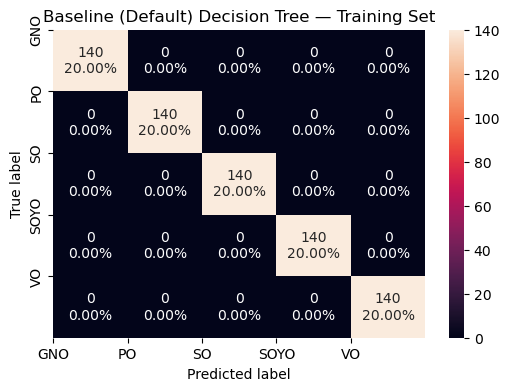

In [12]:
# Draw confusion matrix
confusion_matrix_sklearn(model0, X_train, y_train)

# Get the confusion matrix axes
ax = plt.gca()

# Replace numeric labels with oil names
labels = ['GNO', 'PO', 'SO', 'SOYO', 'VO']

ax.set_xticks(range(len(labels)))
ax.set_yticks(range(len(labels)))

ax.set_xticklabels(labels)
ax.set_yticklabels(labels)

ax.set_title("Baseline (Default) Decision Tree — Training Set")
plt.savefig(r"Images\Oils\default_confusion_matrix_train_oil.jpg",dpi=300,bbox_inches="tight")
plt.show()

In [13]:
decision_tree_default_perf_train = model_performance_classification_sklearn(
    model0, X_train, y_train
)
decision_tree_default_perf_train

,Accuracy,Recall,Precision,F1
0,1.0,1.0,1.0,1.0


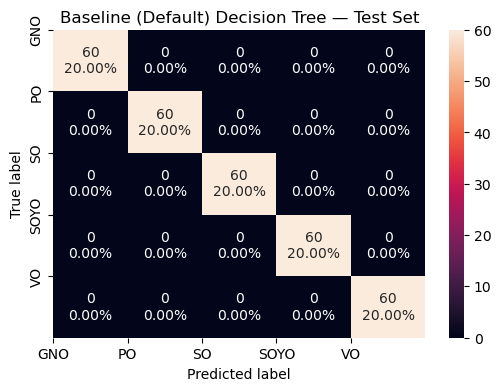

In [14]:
confusion_matrix_sklearn(model0, X_test, y_test)
ax = plt.gca()
labels = ['GNO', 'PO', 'SO', 'SOYO', 'VO']
ax.set_xticks(range(len(labels)))
ax.set_yticks(range(len(labels)))
ax.set_xticklabels(labels)
ax.set_yticklabels(labels)
ax.set_title("Baseline (Default) Decision Tree — Test Set")
plt.savefig(r"Images\Oils\default_confusion_matrix_test_oil.jpg",dpi=300,bbox_inches="tight")
plt.show()

In [15]:
decision_tree_default_perf_test = model_performance_classification_sklearn(
    model0, X_test, y_test
)
decision_tree_default_perf_test

,Accuracy,Recall,Precision,F1
0,1.0,1.0,1.0,1.0


#### Surprisingly high on test data too with 1,500+ features.

In [16]:
sample_rows = X_test.iloc[:3]
# Predict using model0
pred = model0.predict(sample_rows)

# Show results
for i in range(3):
        print(f"---test case {i+1} ---")
        print("Input Features")
        print(sample_rows.iloc[i])
        print("True Label:", y_test.iloc[i])
        print("Predicted Label:", pred[i])
        print()

---test case 1 ---
Input Features
500.8563   -0.756732
501.8205   -0.751811
502.7847   -0.704645
503.749    -0.743113
504.7132   -0.850252
              ...   
2995.329   -1.204371
2996.293   -1.301049
2997.257   -1.390597
2998.221   -1.468161
2999.186   -1.526796
Name: 884, Length: 1866, dtype: float64
True Label: VO
Predicted Label: VO

---test case 2 ---
Input Features
500.8563    0.049363
501.8205    0.319097
502.7847    0.552788
503.749     0.762592
504.7132    0.958637
              ...   
2995.329    0.604436
2996.293    0.699851
2997.257    0.794045
2998.221    0.883586
2999.186    0.963496
Name: 96, Length: 1866, dtype: float64
True Label: SO
Predicted Label: SO

---test case 3 ---
Input Features
500.8563   -0.494559
501.8205   -0.349895
502.7847   -0.317482
503.749    -0.418055
504.7132   -0.591010
              ...   
2995.329    0.438962
2996.293    0.477171
2997.257    0.513081
2998.221    0.545477
2999.186    0.572073
Name: 403, Length: 1866, dtype: float64
True Label: GN

### Prepruning

### Pre‑pruning: small grid search: Search over `max_depth`, `max_leaf_nodes`, `min_samples_split`; keep the model with the **best test recall** and smallest train–test gap.

**Pre-pruning hyperparameters.** `max_depth` caps how many splits deep the tree can grow, `max_leaf_nodes` caps the total number of terminal nodes, and `min_samples_split` requires a node to hold at least that many training samples before it is allowed to split further - all three restrict tree growth *during* fitting, as opposed to the cost-complexity post-pruning further below, which grows a full tree first and prunes it back afterward. `class_weight="balanced"` reweights each training sample by `n_samples / (n_classes * n_samples_of_its_class)`, so a rarer class counts for more in the split criterion; it is applied here (and in post-pruning) for robustness to any class imbalance the train/test split introduces. Hyperparameters are chosen by 5-fold cross-validated weighted recall on the training set only - the test set is not touched until the winning model is evaluated once, at the end.

In [17]:
# Define the parameters of the tree to iterate over
max_depth_values = np.arange(2, 7, 2)
max_leaf_nodes_values = [50, 75, 150, 250]
min_samples_split_values = [10, 30, 50, 70]
cv = 5
verbose = 1
param_grid = {
"max_depth": list(max_depth_values),
"max_leaf_nodes": list(max_leaf_nodes_values),
"min_samples_split": list(min_samples_split_values),
}
search = GridSearchCV(
DecisionTreeClassifier(class_weight="balanced", random_state=1),
param_grid=param_grid,
scoring="recall_weighted",cv= StratifiedKFold(n_splits=cv, shuffle=True, random_state= 1),refit=True,
verbose=verbose)
search.fit(X_train, y_train)

columns = ["params", "mean_test_score", "std_test_score", "rank_test_score"]
cv_results = (pd.DataFrame(search.cv_results_)[columns].sort_values("rank_test_score").reset_index(drop=True)
)

Fitting 5 folds for each of 48 candidates, totalling 240 fits


In [18]:
cv_results.head()

,params,mean_test_score,std_test_score,rank_test_score
0,"{'max_depth': 4, 'max_leaf_nodes': 75, 'min_sa...",0.994286,0.00833,1
1,"{'max_depth': 4, 'max_leaf_nodes': 150, 'min_s...",0.994286,0.00833,1
2,"{'max_depth': 4, 'max_leaf_nodes': 150, 'min_s...",0.994286,0.00833,1
3,"{'max_depth': 4, 'max_leaf_nodes': 250, 'min_s...",0.994286,0.00833,1
4,"{'max_depth': 4, 'max_leaf_nodes': 250, 'min_s...",0.994286,0.00833,1


In [19]:
search.best_estimator_

,criterion,'gini'
,splitter,'best'
,max_depth,np.int64(4)
,min_samples_split,10
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,1
,max_leaf_nodes,50
,min_impurity_decrease,0.0
,class_weight,'balanced'


In [20]:
# creating an instance of the best model
model1 = search.best_estimator_

# fitting the best model to the training data
pred = model1.predict(X_train)

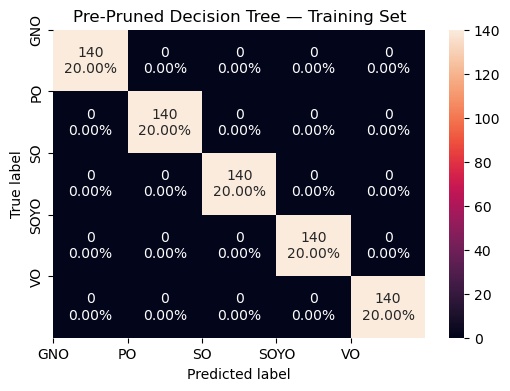

In [21]:
confusion_matrix_sklearn(model1, X_train, y_train)
ax = plt.gca()
labels = ['GNO', 'PO', 'SO', 'SOYO', 'VO']
ax.set_xticks(range(len(labels)))
ax.set_yticks(range(len(labels)))
ax.set_xticklabels(labels)
ax.set_yticklabels(labels)
ax.set_title("Pre-Pruned Decision Tree — Training Set")
plt.savefig(r"Images\Oils\confusion_matrix_train_prepruned_oil.jpg",dpi=300,bbox_inches="tight")
plt.show()

### Visualize the pre‑pruned tree: Plot the structure—useful to see which features split early.

In [22]:
decision_tree_tune_perf_train = model_performance_classification_sklearn(model1, X_train, y_train)
decision_tree_tune_perf_train

,Accuracy,Recall,Precision,F1
0,1.0,1.0,1.0,1.0


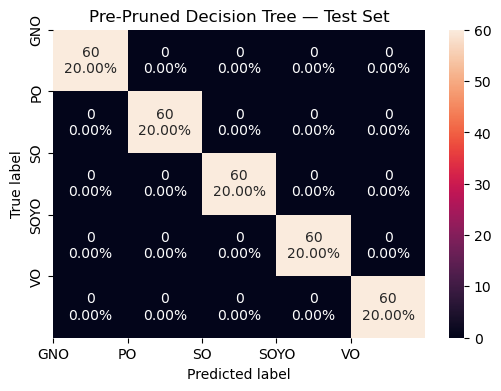

In [23]:
confusion_matrix_sklearn(model1, X_test, y_test)
ax = plt.gca()
labels = ['GNO', 'PO', 'SO', 'SOYO', 'VO']
ax.set_xticks(range(len(labels)))
ax.set_yticks(range(len(labels)))
ax.set_xticklabels(labels)
ax.set_yticklabels(labels)
ax.set_title("Pre-Pruned Decision Tree — Test Set")
plt.savefig(r"Images\Oils\confusion_matrix_test_prepruned_oil.jpg",dpi=300,bbox_inches="tight")
plt.show()

In [24]:
decision_tree_tune_perf_test = model_performance_classification_sklearn(
    model1, X_test, y_test
)
decision_tree_tune_perf_test

,Accuracy,Recall,Precision,F1
0,1.0,1.0,1.0,1.0


### Save indices/importances for later reuse

In [25]:
feature_names = list(X_train.columns)
importances = model1.feature_importances_
indices = np.argsort(importances)

### Plot the tree

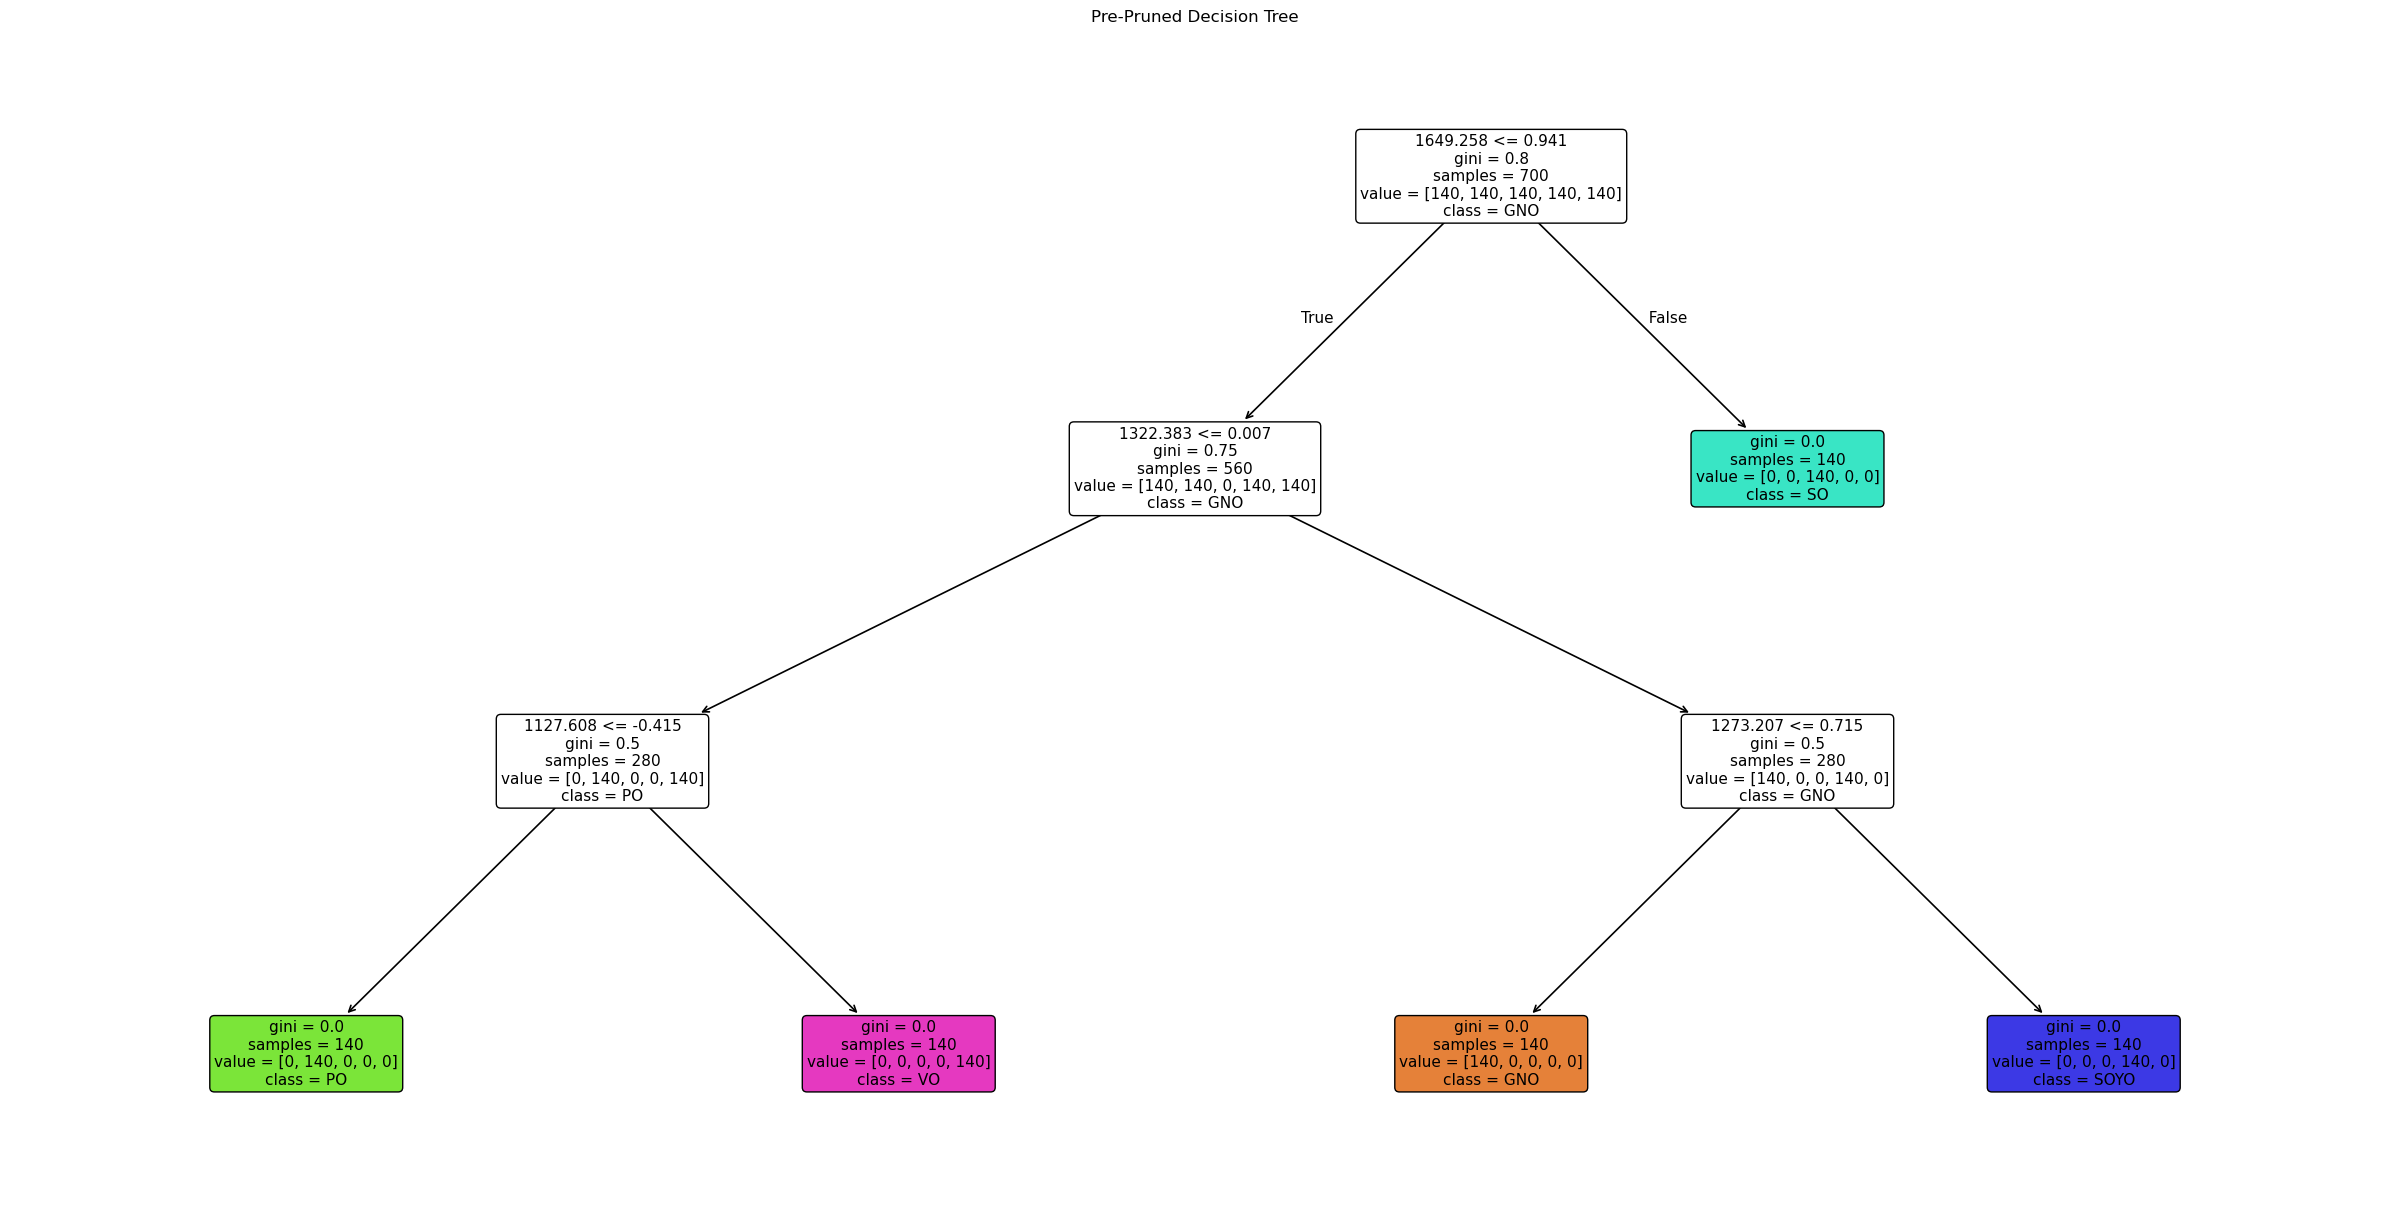

In [26]:
class_names = ['GNO', 'PO', 'SO', 'SOYO', 'VO']

plt.figure(figsize=(24, 12))

out = tree.plot_tree(
    model1,
    feature_names=feature_names,
    class_names=class_names,   # <-- adds class names
    filled=True,
    rounded=True,
    impurity=True,
    proportion=False,          # <-- keeps actual counts
    fontsize=11,
    node_ids=False
)

for o in out:
    arrow = o.arrow_patch
    if arrow is not None:
        arrow.set_edgecolor("black")
        arrow.set_linewidth(1.2)

plt.tight_layout()

plt.title("Pre-Pruned Decision Tree")
plt.savefig(r"Images\Oils\Prepruned_Decision_Tree_oils.jpg",dpi=600,bbox_inches="tight")
plt.show()

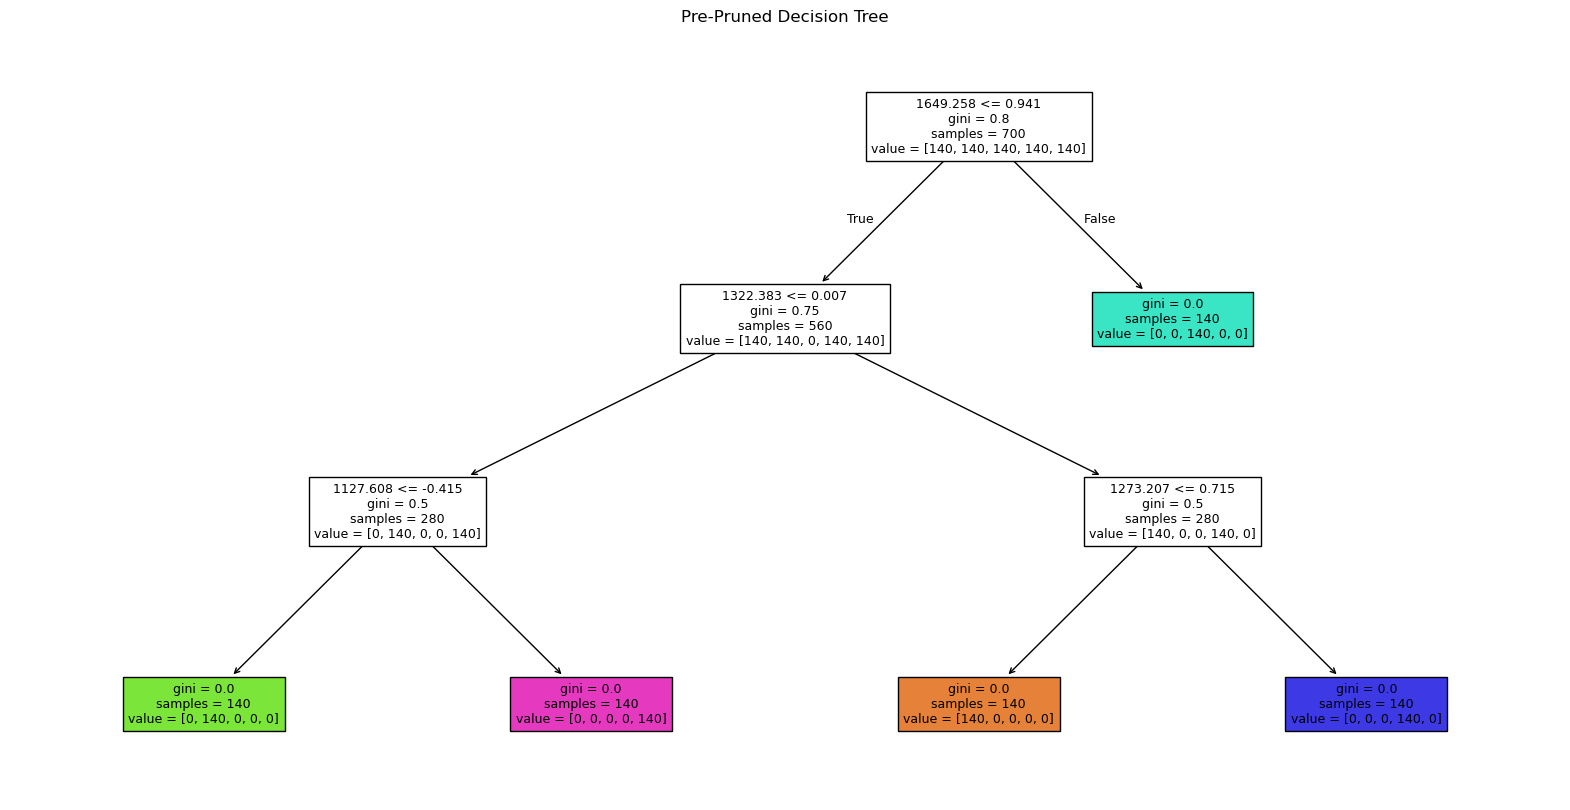

In [27]:
plt.figure(figsize=(20, 10))
out = tree.plot_tree(
    model1,
    feature_names=feature_names,
    filled=True,
    fontsize=9,
    node_ids=False,
    class_names=None,
)
# below code will add arrows to the decision tree split if they are missing
for o in out:
    arrow = o.arrow_patch
    if arrow is not None:
        arrow.set_edgecolor("black")
        arrow.set_linewidth(1)
plt.title("Pre-Pruned Decision Tree")
plt.show()

In [28]:
for i, name in enumerate(le.classes_):
    print(f"{i}: {name}")

0: GNO
1: PO
2: SO
3: SOYO
4: VO


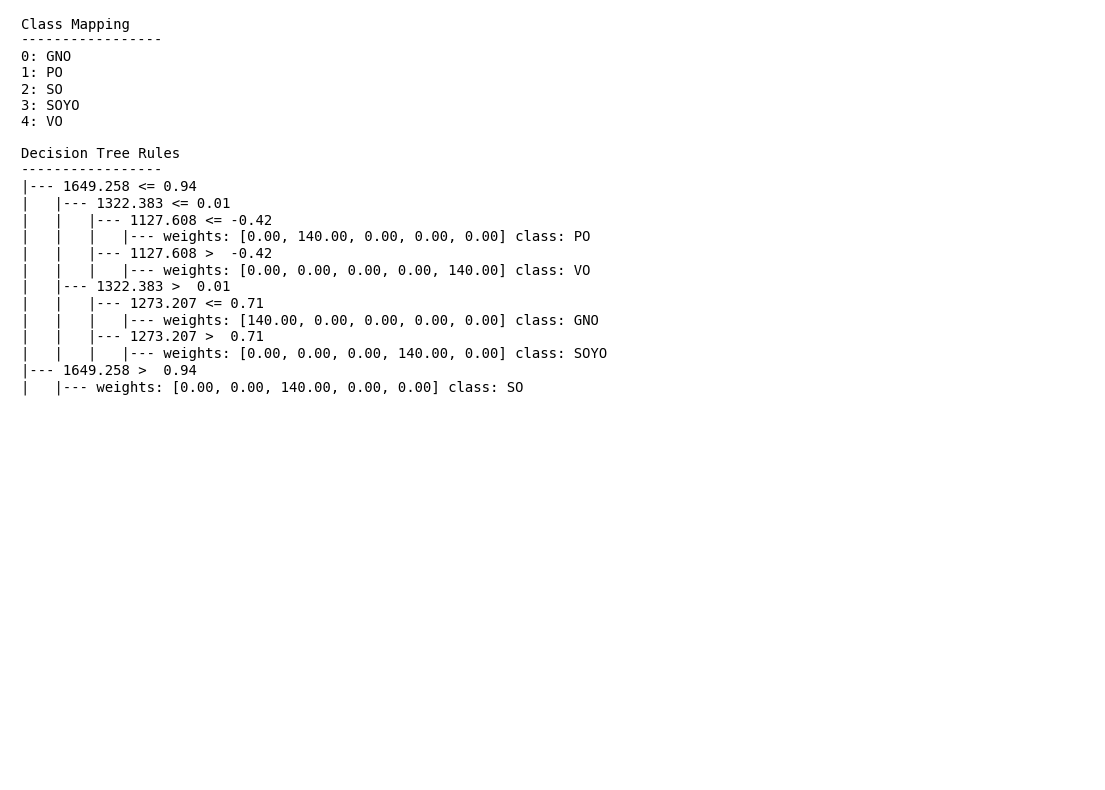

In [29]:
# Create text report
report = tree.export_text(
    model1,
    feature_names=feature_names,
    show_weights=True
)

# Add class mapping at top
mapping_text = "\n".join(
    [f"{i}: {name}" for i, name in enumerate(le.classes_)]
)

full_report = (
    "Class Mapping\n"
    "-----------------\n"
    f"{mapping_text}\n\n"
    "Decision Tree Rules\n"
    "-----------------\n"
    f"{report}"
)

# Create figure
fig, ax = plt.subplots(figsize=(14, 10))
ax.axis("off")

ax.text(
    0.01,
    0.99,
    full_report,
    family="monospace",
    fontsize=10,
    va="top"
)

plt.savefig(r"Images\Oils\Prepruned_Decision_Tree_Text_Report_Oils.jpg",dpi=600,bbox_inches="tight")
plt.show()

In [30]:
# Text report showing the rules of a decision tree -
print(tree.export_text(model1, feature_names=feature_names, show_weights=True))

|--- 1649.258 <= 0.94
|   |--- 1322.383 <= 0.01
|   |   |--- 1127.608 <= -0.42
|   |   |   |--- weights: [0.00, 140.00, 0.00, 0.00, 0.00] class: PO
|   |   |--- 1127.608 >  -0.42
|   |   |   |--- weights: [0.00, 0.00, 0.00, 0.00, 140.00] class: VO
|   |--- 1322.383 >  0.01
|   |   |--- 1273.207 <= 0.71
|   |   |   |--- weights: [140.00, 0.00, 0.00, 0.00, 0.00] class: GNO
|   |   |--- 1273.207 >  0.71
|   |   |   |--- weights: [0.00, 0.00, 0.00, 140.00, 0.00] class: SOYO
|--- 1649.258 >  0.94
|   |--- weights: [0.00, 0.00, 140.00, 0.00, 0.00] class: SO



In [31]:
importances = model1.feature_importances_
importances

array([0., 0., 0., ..., 0., 0., 0.], shape=(1866,))

In [32]:
print(np.sum(importances > 0))

4


**Reading feature importance.** scikit-learn's Gini importance for a wavenumber sums the (sample-weighted) impurity decrease at every split in the tree that used it, then normalizes so all importances sum to 1. It reflects how much a wavenumber helped separate classes *within this specific tree*, not a model-free measure of how discriminative that Raman band is in isolation: because neighboring wavenumbers are highly correlated, the tree only needs to pick one of several near-equivalent candidates at a split, so an unused neighbor can be just as chemically informative as a used one that scores higher here. Only wavenumbers actually used by a split get a nonzero score, which is why the plot below only shows that nonzero subset.

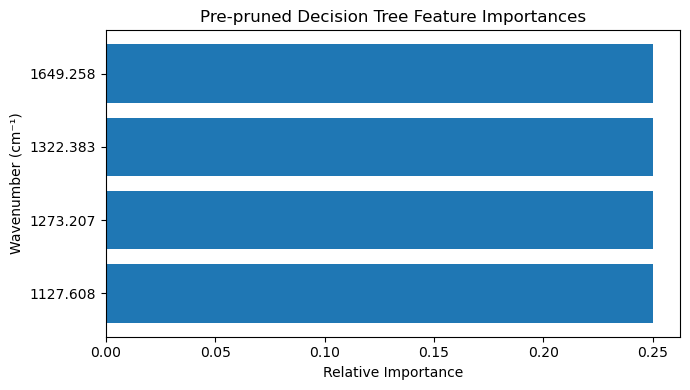

In [33]:
importances = model1.feature_importances_

# Keep only features used by the tree
mask = importances > 0

important_features = np.array(feature_names)[mask]
important_values = importances[mask]

# Sort by importance
idx = np.argsort(important_values)

plt.figure(figsize=(7,4))

plt.barh(
    range(len(idx)),
    important_values[idx]
)

plt.yticks(
    range(len(idx)),
    important_features[idx]
)

plt.xlabel("Relative Importance")
plt.ylabel("Wavenumber (cm⁻¹)")
plt.title("Pre-pruned Decision Tree Feature Importances")

plt.tight_layout()

plt.savefig(r"Images\Oils\decision_tree_feature_importance_oils.jpg",dpi=600,bbox_inches="tight")
plt.show()

In [34]:
for f, imp in zip(feature_names, importances):
    if imp > 0:
        print(f"{f} : {imp:.4f}")

1127.608 : 0.2500
1273.207 : 0.2500
1322.383 : 0.2500
1649.258 : 0.2500


In [35]:
df_oils.head()

,Oil_Type,Oil,500.8563,501.8205,502.7847,503.749,504.7132,505.6774,506.6417,507.6059,...,2990.507,2991.472,2992.436,2993.4,2994.364,2995.329,2996.293,2997.257,2998.221,2999.186
0,SO 0,SO,-0.458101,-1.495276,-1.862568,-1.831711,-1.535953,-0.993022,-0.391103,0.233167,...,0.322414,0.412911,0.510324,0.615980,0.714031,0.843851,0.954011,1.039072,1.095093,1.117694
1,SO 0,SO,0.068097,-0.399315,-0.678853,-0.814568,-0.855950,-0.791816,-0.674305,-0.513736,...,0.455966,0.500148,0.580671,0.709734,0.841224,0.943207,1.009186,1.037642,1.027740,0.978225
2,SO 0,SO,0.167223,-1.133351,-1.652558,-1.617278,-1.226656,-0.573671,0.003154,0.458940,...,0.567724,0.764727,0.917556,0.995929,1.028447,1.063251,1.095276,1.128665,1.164110,1.198602
3,SO 0,SO,-0.271799,-0.583166,-0.724528,-0.798817,-0.848749,-0.863939,-0.920526,-1.022233,...,0.305283,0.384108,0.568860,0.766478,0.917478,1.028797,1.115378,1.180302,1.224556,1.246197
4,SO 0,SO,-0.194513,-0.940731,-1.160886,-1.062074,-0.771085,-0.351588,-0.068750,0.085753,...,0.686066,0.809774,0.949498,1.038355,1.068043,1.113757,1.151863,1.185146,1.213659,1.234257


In [36]:
# Get wavenumbers/features used by the decision tree
important_features = [
    f for f, imp in zip(feature_names, importances)
    if imp > 0
]

# Keep the 'Oil' column + important wavenumbers
df_features = df_oils[['Oil'] + important_features].copy()

# Check the result
df_features.head()

,Oil,1127.608,1273.207,1322.383,1649.258
0,SO,-0.650799,0.612717,-0.219153,1.781826
1,SO,-0.780761,0.511428,-0.294802,1.785679
2,SO,-0.691794,0.524600,-0.171647,1.864622
3,SO,-0.867883,0.484229,-0.183371,1.947268
4,SO,-0.789562,0.570877,-0.301785,1.954528


In [37]:
df_features.to_csv(r"Images\Oils\df_features.csv", index=False)

In [38]:
df_features.info(memory_usage = 'deep')

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 5 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Oil       1000 non-null   object 
 1   1127.608  1000 non-null   float64
 2   1273.207  1000 non-null   float64
 3   1322.383  1000 non-null   float64
 4   1649.258  1000 non-null   float64
dtypes: float64(4), object(1)
memory usage: 81.8 KB


In [39]:
# ---------------------------------------------------------
# Test classification using ONLY the 4 DT-selected wavenumbers
# ---------------------------------------------------------

# The 4 wavenumbers selected by the pre-pruned decision tree
selected_wavenumbers = ['1127.608','1273.207','1322.383','1649.258']

# X = only the 4 selected wavenumbers
X_4 = df_features[selected_wavenumbers].astype(float)

# Target
y_4 = df_features['Oil']

# Same train/test split used in the original notebook
X_train_4, X_test_4, y_train_4, y_test_4 = train_test_split(
    X_4,
    y_4,
    test_size=0.30,
    random_state=1,
    stratify=y_4
)

# Build the decision tree using ONLY these 4 wavenumbers
model_4 = DecisionTreeClassifier(
    class_weight="balanced",
    max_depth=4,
    max_leaf_nodes=50,
    min_samples_split=10,
    random_state=1
)

# Fit
model_4.fit(X_train_4, y_train_4)

# Predictions
y_train_pred_4 = model_4.predict(X_train_4)
y_test_pred_4 = model_4.predict(X_test_4)

# ---------------------------------------------------------
# Performance
# ---------------------------------------------------------

train_accuracy_4 = accuracy_score(y_train_4, y_train_pred_4)
test_accuracy_4 = accuracy_score(y_test_4, y_test_pred_4)

train_recall_4 = recall_score(y_train_4, y_train_pred_4, average='weighted')
test_recall_4 = recall_score(y_test_4, y_test_pred_4, average='weighted')

train_precision_4 = precision_score(y_train_4, y_train_pred_4, average='weighted')
test_precision_4 = precision_score(y_test_4, y_test_pred_4, average='weighted')

train_f1_4 = f1_score(y_train_4, y_train_pred_4, average='weighted')
test_f1_4 = f1_score(y_test_4, y_test_pred_4, average='weighted')

print("Using ONLY these 4 wavenumbers:")
print(selected_wavenumbers)

print("\nTraining Performance")
print("--------------------")
print(f"Accuracy  : {train_accuracy_4:.4f}")
print(f"Recall    : {train_recall_4:.4f}")
print(f"Precision : {train_precision_4:.4f}")
print(f"F1 Score  : {train_f1_4:.4f}")

print("\nTest Performance")
print("----------------")
print(f"Accuracy  : {test_accuracy_4:.4f}")
print(f"Recall    : {test_recall_4:.4f}")
print(f"Precision : {test_precision_4:.4f}")
print(f"F1 Score  : {test_f1_4:.4f}")

Using ONLY these 4 wavenumbers:
['1127.608', '1273.207', '1322.383', '1649.258']

Training Performance
--------------------
Accuracy  : 1.0000
Recall    : 1.0000
Precision : 1.0000
F1 Score  : 1.0000

Test Performance
----------------
Accuracy  : 1.0000
Recall    : 1.0000
Precision : 1.0000
F1 Score  : 1.0000


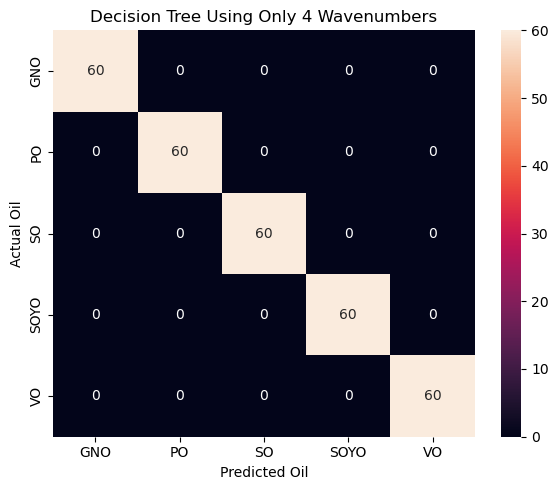

In [40]:
# Confusion matrix for the 4-wavenumber model

cm_4 = confusion_matrix(y_test_4, y_test_pred_4)

labels = sorted(y_4.unique())

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm_4,
    annot=True,
    fmt='d',
    xticklabels=labels,
    yticklabels=labels
)

plt.xlabel("Predicted Oil")
plt.ylabel("Actual Oil")
plt.title("Decision Tree Using Only 4 Wavenumbers")

plt.tight_layout()

plt.savefig(
    r"Images\Oils\confusion_matrix_test_4_wavenumbers_oils.jpg",
    dpi=600,
    bbox_inches="tight"
)

plt.show()

In [41]:
# Verify 100% correct classification
results_4 = pd.DataFrame({
    'Actual': y_test_4.values,
    'Predicted': y_test_pred_4
})

results_4['Correct'] = results_4['Actual'] == results_4['Predicted']

print(results_4['Correct'].value_counts())

print("\nNumber of incorrect predictions:",
      (~results_4['Correct']).sum())

print("Test samples:",
      len(results_4))

print("Test accuracy:",
      results_4['Correct'].mean())

Correct
True    300
Name: count, dtype: int64

Number of incorrect predictions: 0
Test samples: 300
Test accuracy: 1.0


### Post-pruning

### Post‑pruning via Cost‑Complexity Path: Compute `ccp_alphas` and impurities to study pruning trajectory.

For a fully grown tree *T*, cost-complexity pruning defines

R_α(T) = R(T) + α·|leaves(T)|

where R(T) is T's total training impurity and |leaves(T)| its number of leaves. α trades fit against size: α = 0 is the fully grown tree, and increasing α makes larger subtrees costlier, until at each of a finite sequence of α values the optimal subtree collapses its weakest-link node. `cost_complexity_pruning_path` returns exactly that sequence of α values and each one's corresponding leaf impurity.

In [42]:
clf = DecisionTreeClassifier(random_state=1, class_weight="balanced")
path = clf.cost_complexity_pruning_path(X_train, y_train)
# sklearn's ccp_alphas are already >= 0 in practice; abs() guards against a
# stray floating-point sign flip on a value that should be exactly 0.
ccp_alphas, impurities = abs(path.ccp_alphas), path.impurities

In [43]:
pd.DataFrame(path)

,ccp_alphas,impurities
0,0.0,0.0
1,0.2,0.6
2,0.2,0.8


### Impurity vs α (training) from the above summary: Heavier pruning (larger α) reduces tree size and increases leaf impurity.


In [44]:
print(model1.get_n_leaves())
print(model1.get_depth())

5
3


In [45]:
alphas = path.ccp_alphas

for alpha in alphas:
    clf = DecisionTreeClassifier(random_state=1,ccp_alpha=alpha)
    clf.fit(X_train, y_train)

    print(
        f"alpha={alpha:.6f}",
        "depth=", clf.get_depth(),
        "leaves=", clf.get_n_leaves()
    )

alpha=0.000000 depth= 3 leaves= 5
alpha=0.200000 depth= 1 leaves= 2
alpha=0.200000 depth= 0 leaves= 1


alpha=0.200000 depth= 1 leaves= 2


alpha=0.200000 depth= 0 leaves= 1


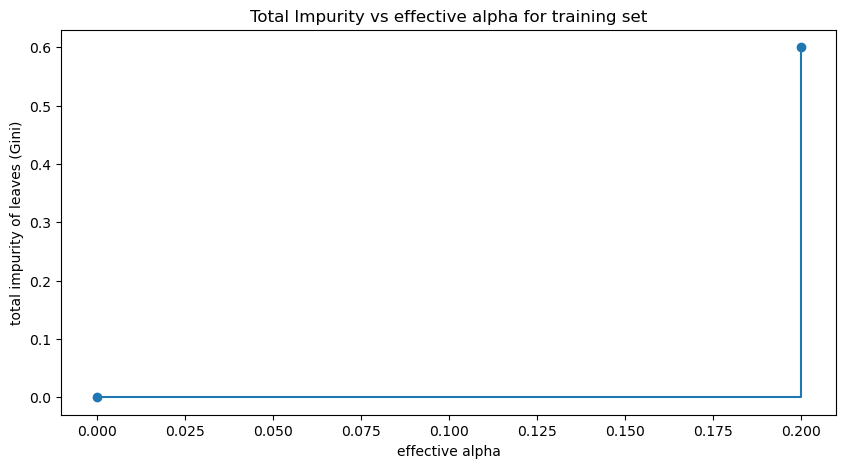

In [46]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(ccp_alphas[:-1], impurities[:-1], marker="o", drawstyle="steps-post")
ax.set_xlabel("effective alpha")
ax.set_ylabel("total impurity of leaves (Gini)")
ax.set_title("Total Impurity vs effective alpha for training set")
plt.show()

### Fit trees across α values: Train a sequence of pruned trees; we’ll compare metrics across α.


In [47]:
clfs = []
for ccp_alpha in ccp_alphas:
    clf = DecisionTreeClassifier(random_state=1, ccp_alpha=ccp_alpha, class_weight="balanced")
    clf.fit(X_train, y_train)
    clfs.append(clf)
print("Number of nodes in the last tree is: {} with ccp_alpha: {}".format(clfs[-1].tree_.node_count, ccp_alphas[-1]))

Number of nodes in the last tree is: 1 with ccp_alpha: 0.20000000000000007


In [48]:
param_grid = {"ccp_alpha": list(ccp_alphas)}
search = GridSearchCV(DecisionTreeClassifier(random_state=1, class_weight='balanced'),param_grid=param_grid,
scoring="recall_weighted",cv=StratifiedKFold(n_splits= 5, shuffle=True, random_state=1),refit=True,
verbose= 1)
search.fit(X_train, y_train)

cv_table = pd.DataFrame({
"ccp_alpha": param_grid["ccp_alpha"],
"mean_cv_recall": search.cv_results_["mean_test_score"],
"std_cv_recall": search.cv_results_["std_test_score"],
}).sort_values("ccp_alpha").reset_index(drop=True)

Fitting 5 folds for each of 3 candidates, totalling 15 fits


In [49]:
model2 = search.best_estimator_
cv_table.head()

,ccp_alpha,mean_cv_recall,std_cv_recall
0,0.0,0.994286,0.00833
1,0.2,0.994286,0.00833
2,0.2,0.200000,0.00000


### Node count / Depth vs α: Sanity‑check that pruning controls complexity as expected.

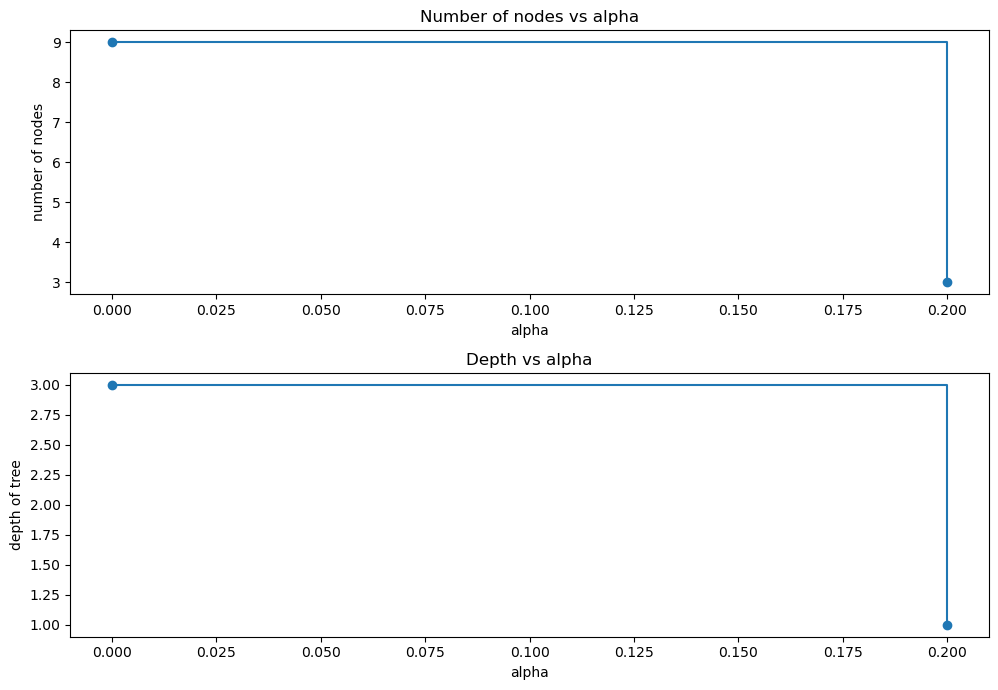

In [50]:
# Drop the last alpha: it always collapses the tree to a single root node
# (uninformative) - see the last line printed in the loop above (leaves=1).
clfs = clfs[:-1]
ccp_alphas = ccp_alphas[:-1]

node_counts = [clf.tree_.node_count for clf in clfs]
depth = [clf.tree_.max_depth for clf in clfs]
fig, ax = plt.subplots(2, 1, figsize=(10, 7))
ax[0].plot(ccp_alphas, node_counts, marker="o", drawstyle="steps-post")
ax[0].set_xlabel("alpha")
ax[0].set_ylabel("number of nodes")
ax[0].set_title("Number of nodes vs alpha")
ax[1].plot(ccp_alphas, depth, marker="o", drawstyle="steps-post")
ax[1].set_xlabel("alpha")
ax[1].set_ylabel("depth of tree")
ax[1].set_title("Depth vs alpha")
fig.tight_layout()

### Recall vs α (Train/Test): Pick α giving the best generalization

In [51]:
recall_train = []
for clf in clfs:
    pred_train = clf.predict(X_train)
    values_train = recall_score(y_train, pred_train, average='weighted')
    recall_train.append(values_train)

In [52]:
recall_test = []
for clf in clfs:
    pred_test = clf.predict(X_test)
    values_test = recall_score(y_test, pred_test, average='weighted')
    recall_test.append(values_test)

In [53]:
train_scores = [clf.score(X_train, y_train) for clf in clfs]
test_scores = [clf.score(X_test, y_test) for clf in clfs]

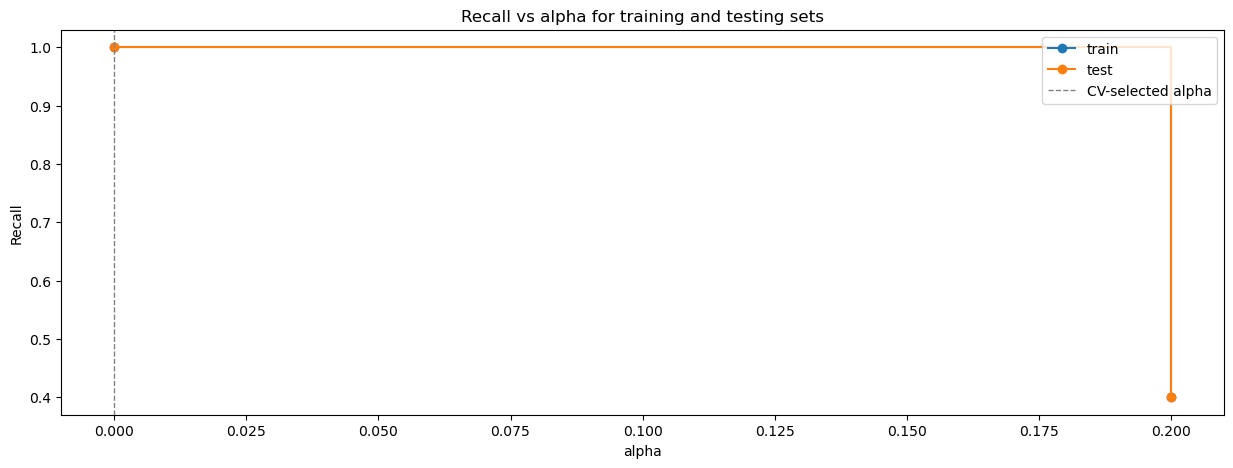

In [54]:
fig, ax = plt.subplots(figsize=(15, 5))
ax.set_xlabel("alpha")
ax.set_ylabel("Recall")
ax.set_title("Recall vs alpha for training and testing sets")
ax.plot(
    ccp_alphas, recall_train, marker="o", label="train", drawstyle="steps-post",
)
ax.plot(ccp_alphas, recall_test, marker="o", label="test", drawstyle="steps-post")
ax.axvline(model2.ccp_alpha, color="gray", linestyle="--", linewidth=1, label="CV-selected alpha")
ax.legend()
plt.show()

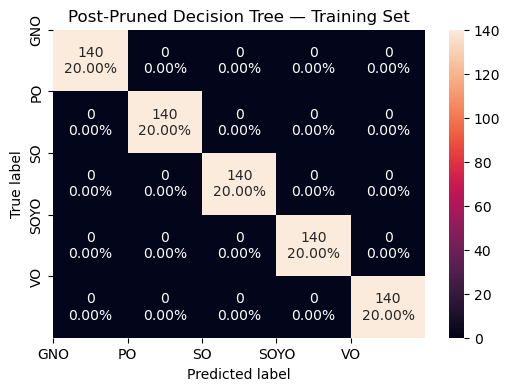

In [55]:
model3 = model2
confusion_matrix_sklearn(model3, X_train, y_train)
ax = plt.gca()
labels = ['GNO', 'PO', 'SO', 'SOYO', 'VO']
ax.set_xticks(range(len(labels)))
ax.set_yticks(range(len(labels)))
ax.set_xticklabels(labels)
ax.set_yticklabels(labels)
ax.set_title("Post-Pruned Decision Tree — Training Set")
plt.savefig(r"Images\Oils\confusion_matrix_train_postpruned_oil.jpg",dpi=300,bbox_inches="tight")
plt.show()

In [56]:
decision_tree_post_perf_train = model_performance_classification_sklearn(
    model3, X_train, y_train
)
decision_tree_post_perf_train

,Accuracy,Recall,Precision,F1
0,1.0,1.0,1.0,1.0


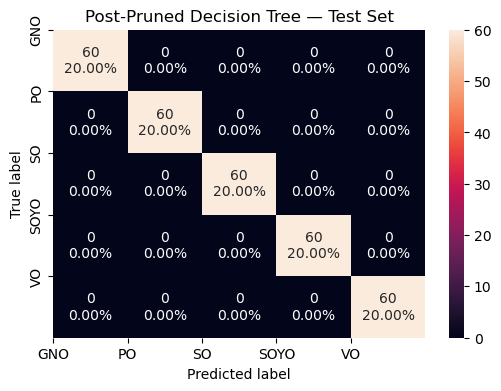

In [57]:
model3 = model2
confusion_matrix_sklearn(model3, X_test, y_test)
ax = plt.gca()
labels = ['GNO', 'PO', 'SO', 'SOYO', 'VO']
ax.set_xticks(range(len(labels)))
ax.set_yticks(range(len(labels)))
ax.set_xticklabels(labels)
ax.set_yticklabels(labels)
ax.set_title("Post-Pruned Decision Tree — Test Set")
plt.savefig(r"Images\Oils\confusion_matrix_test_postpruned_oil.jpg",dpi=300,bbox_inches="tight")
plt.show()

In [58]:
decision_tree_post_test = model_performance_classification_sklearn(
    model3, X_test, y_test
)
decision_tree_post_test

,Accuracy,Recall,Precision,F1
0,1.0,1.0,1.0,1.0


### decision tree for post-pruning

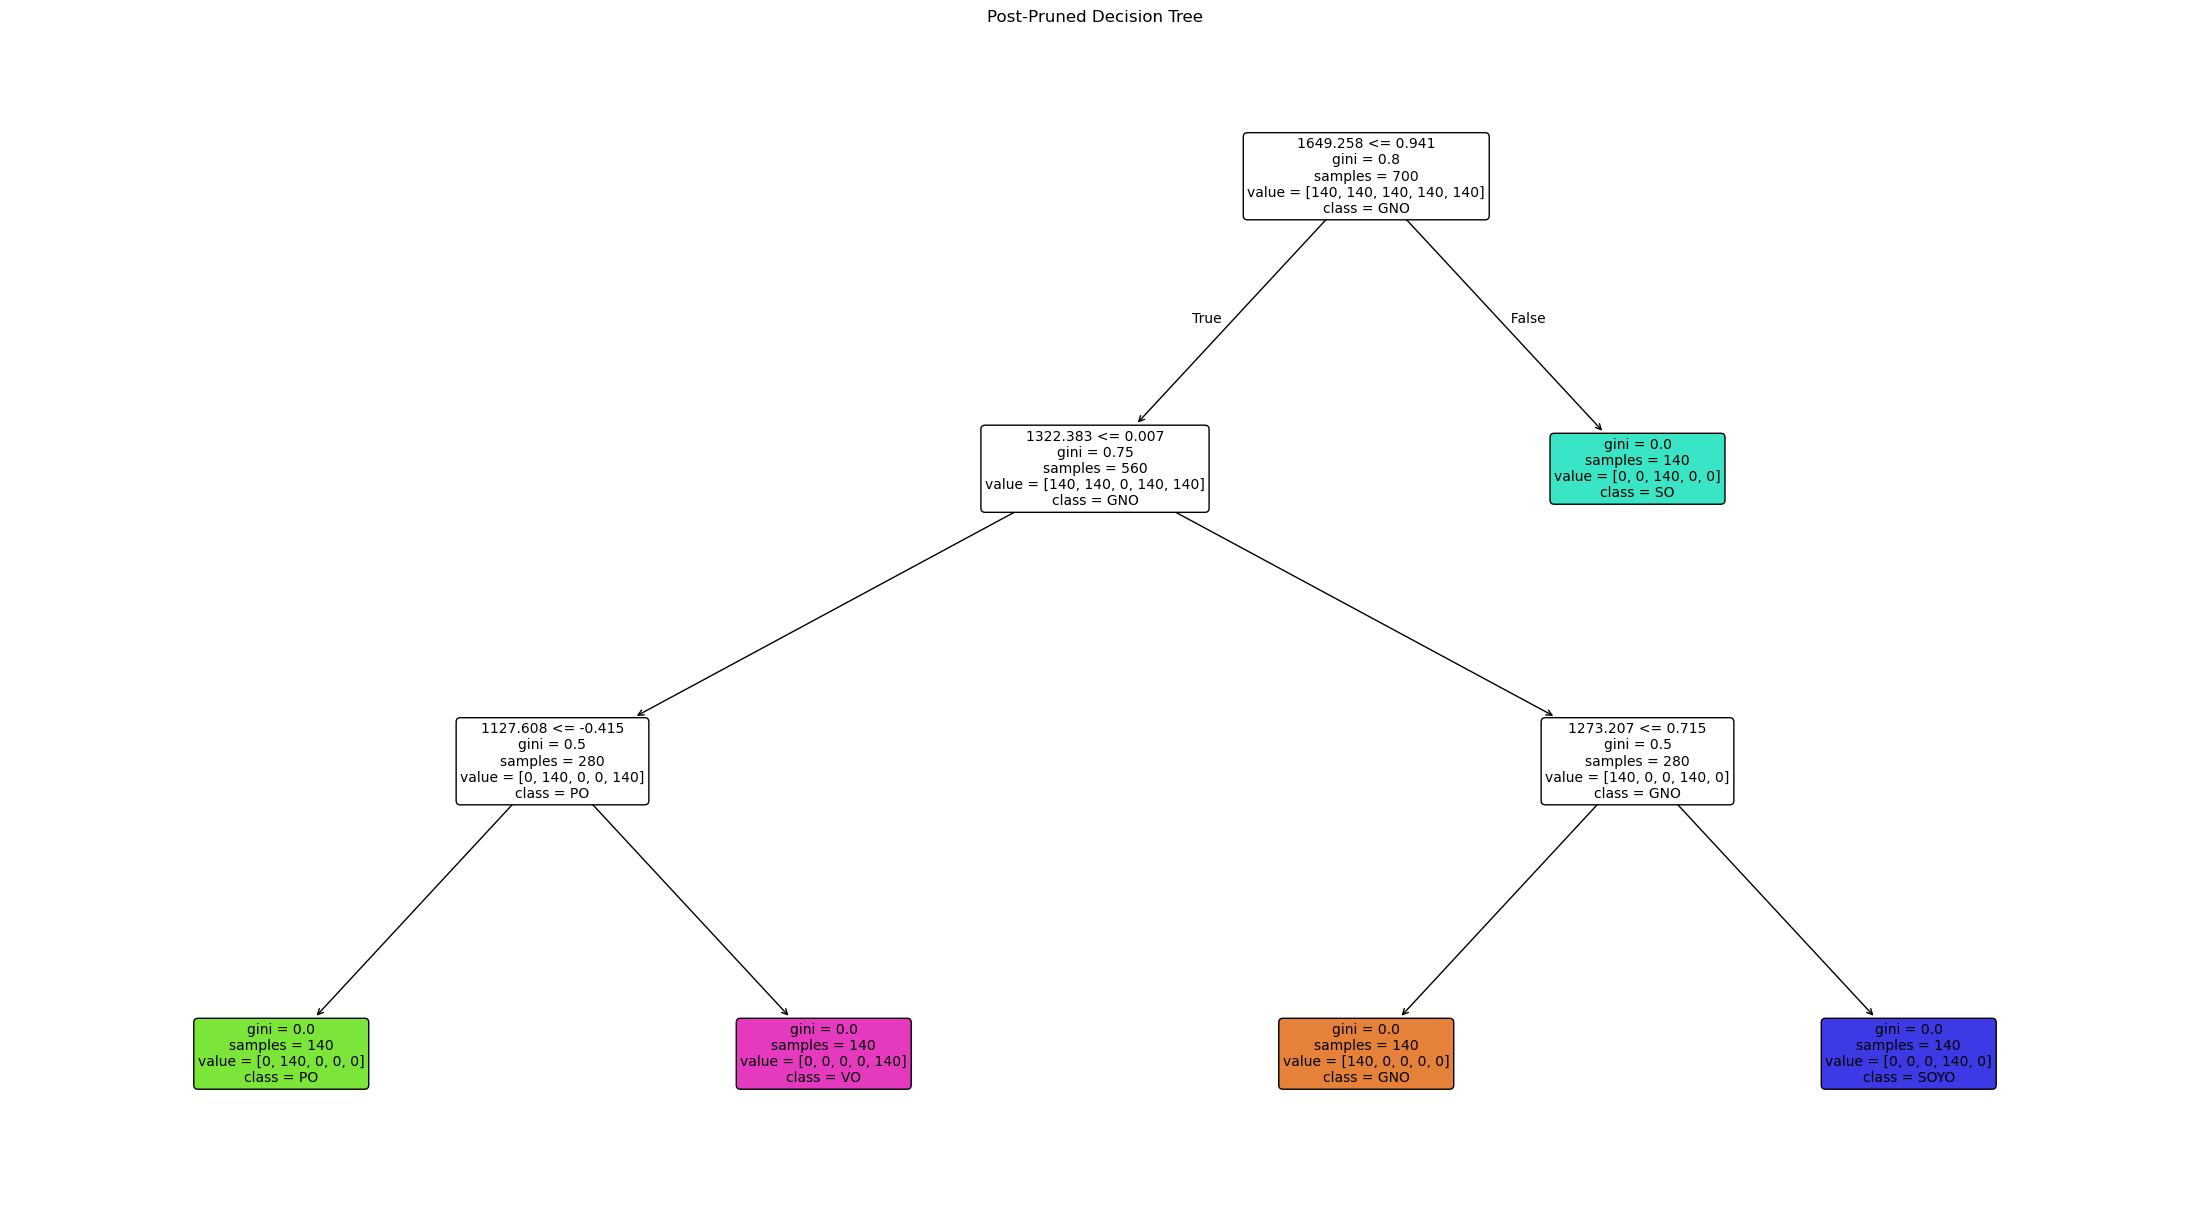

In [59]:
class_names = ['GNO', 'PO', 'SO', 'SOYO', 'VO']
plt.figure(figsize=(22, 12))

out = tree.plot_tree(
    model3,
    feature_names=feature_names,
    class_names=class_names,   # <-- add class labels
    filled=True,
    rounded=True,
    fontsize=10,
    node_ids=False,
    proportion=False,          # keep sample counts
    impurity=True              # keep gini values
)

# Make arrows darker
for o in out:
    arrow = o.arrow_patch
    if arrow is not None:
        arrow.set_edgecolor("black")
        arrow.set_linewidth(1)

plt.tight_layout()

plt.title("Post-Pruned Decision Tree")
plt.savefig(r"Images\Oils\postpruned_decision_tree_oils.jpg",dpi=600,bbox_inches="tight")
plt.show()

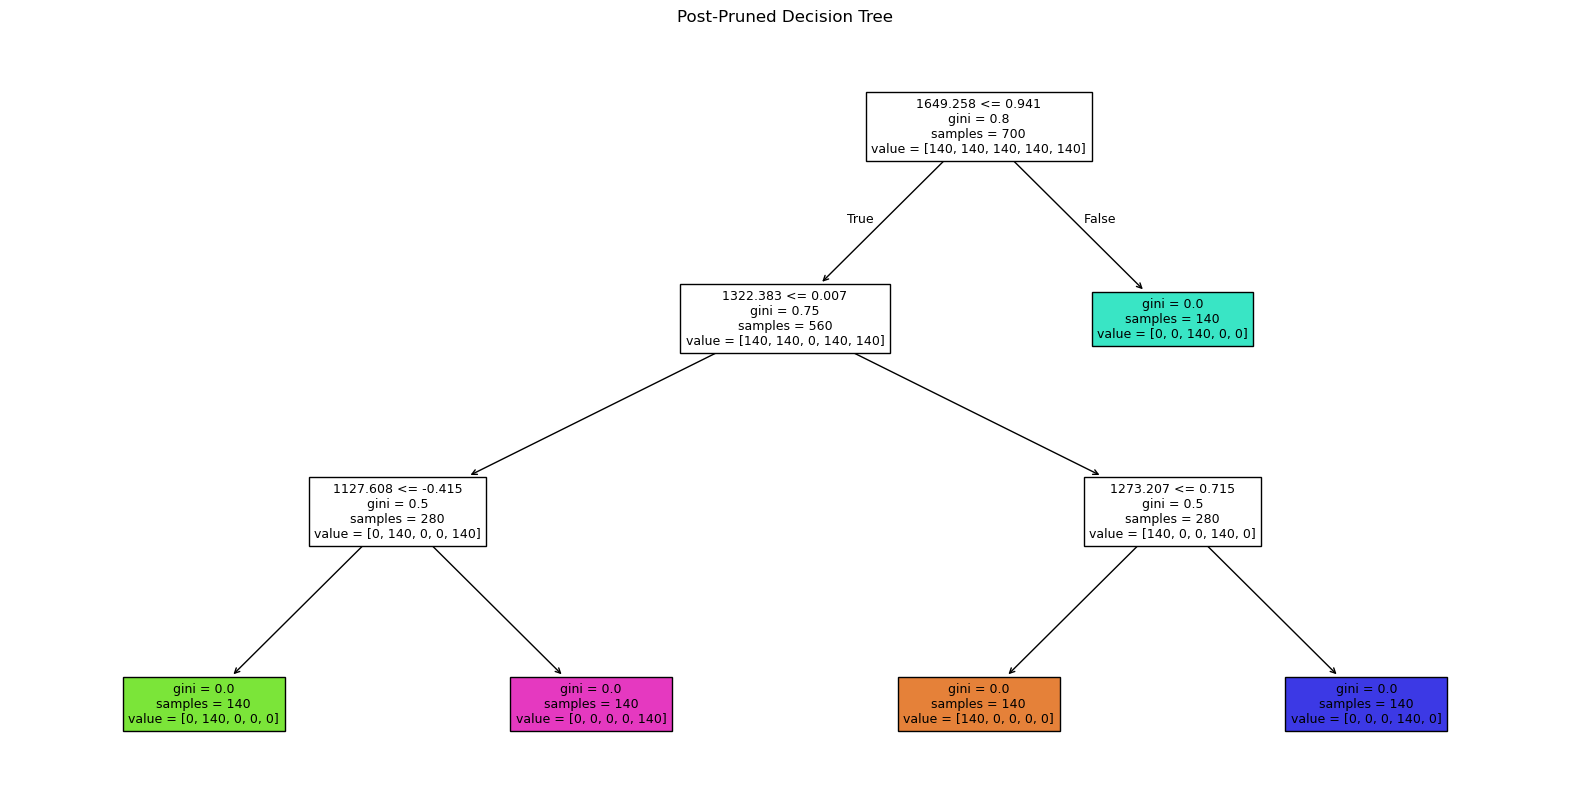

In [60]:
plt.figure(figsize=(20, 10))

out = tree.plot_tree(
    model3,
    feature_names=feature_names,
    filled=True,
    fontsize=9,
    node_ids=False,
    class_names=None,
)
for o in out:
    arrow = o.arrow_patch
    if arrow is not None:
        arrow.set_edgecolor("black")
        arrow.set_linewidth(1)
plt.title("Post-Pruned Decision Tree")
plt.show()

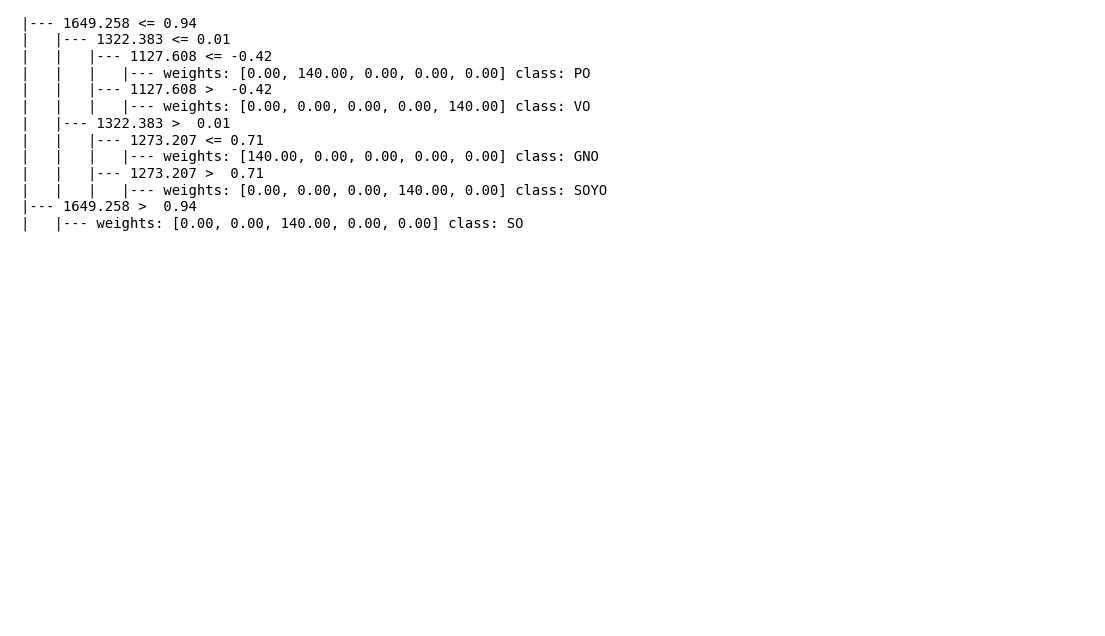

In [61]:
report = tree.export_text(
    model3,
    feature_names=feature_names,
    show_weights=True
)

fig, ax = plt.subplots(figsize=(14, 8))
ax.axis("off")

ax.text(
    0.01,
    0.99,
    report,
    transform=ax.transAxes,
    fontsize=10,
    family="monospace",
    va="top"
)

plt.savefig(r"Images\Oils\postpruned_tree_rules_oils.jpg",dpi=600,bbox_inches="tight")
plt.show()

In [62]:
# Text report showing the rules of a decision tree -
print(tree.export_text(model3, feature_names=feature_names, show_weights=True))

|--- 1649.258 <= 0.94
|   |--- 1322.383 <= 0.01
|   |   |--- 1127.608 <= -0.42
|   |   |   |--- weights: [0.00, 140.00, 0.00, 0.00, 0.00] class: PO
|   |   |--- 1127.608 >  -0.42
|   |   |   |--- weights: [0.00, 0.00, 0.00, 0.00, 140.00] class: VO
|   |--- 1322.383 >  0.01
|   |   |--- 1273.207 <= 0.71
|   |   |   |--- weights: [140.00, 0.00, 0.00, 0.00, 0.00] class: GNO
|   |   |--- 1273.207 >  0.71
|   |   |   |--- weights: [0.00, 0.00, 0.00, 140.00, 0.00] class: SOYO
|--- 1649.258 >  0.94
|   |--- weights: [0.00, 0.00, 140.00, 0.00, 0.00] class: SO



In [63]:
importances = model3.feature_importances_
indices = np.argsort(importances)

In [64]:
np.sum(importances > 0)

np.int64(4)

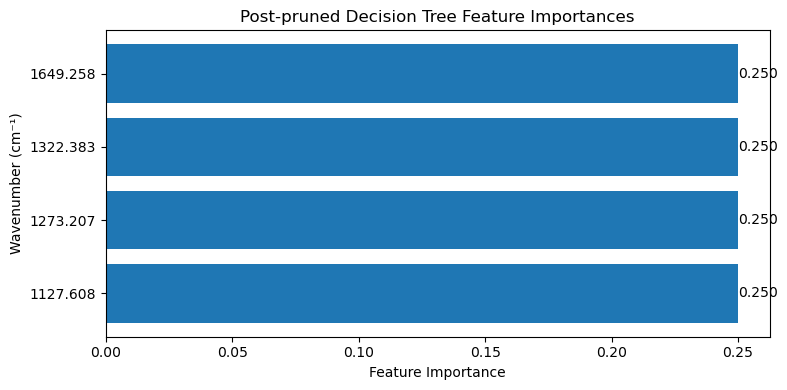

In [65]:
importances = model3.feature_importances_

# Keep only important features
mask = importances > 0

important_features = np.array(feature_names)[mask]
important_importances = importances[mask]

# Sort
idx = np.argsort(important_importances)

plt.figure(figsize=(8,4))

plt.barh(
    important_features[idx],
    important_importances[idx]
)

plt.xlabel("Feature Importance")
plt.ylabel("Wavenumber (cm⁻¹)")
plt.title("Post-pruned Decision Tree Feature Importances")

# Print values on bars
for i, v in enumerate(important_importances[idx]):
    plt.text(v, i, f"{v:.3f}", va="center")

plt.tight_layout()
plt.savefig(r"Images\Oils\PostPruned_Feature_Importance_oils.jpg",dpi=600,bbox_inches="tight")
plt.show()

In [66]:
imp_df = pd.DataFrame({
    "Wavenumber": np.array(feature_names)[mask],
    "Importance": importances[mask]
})

imp_df = imp_df.sort_values(
    "Importance",
    ascending=False
)

print(imp_df)

  Wavenumber  Importance
0   1127.608        0.25
1   1273.207        0.25
2   1322.383        0.25
3   1649.258        0.25


### Comparision

In [67]:
# training performance comparison
models_train_comp_df = pd.concat(
    [
        decision_tree_default_perf_train.T,
        decision_tree_tune_perf_train.T,
        decision_tree_post_perf_train.T,
    ],
    axis=1,
)
models_train_comp_df.columns = [
    "Decision Tree (sklearn default)",
    "Decision Tree (Pre-Pruning)",
    "Decision Tree (Post-Pruning)",
]
print("Training performance comparison:")
models_train_comp_df

Training performance comparison:


,Decision Tree (sklearn default),Decision Tree (Pre-Pruning),Decision Tree (Post-Pruning)
Accuracy,1.0,1.0,1.0
Recall,1.0,1.0,1.0
Precision,1.0,1.0,1.0
F1,1.0,1.0,1.0


In [68]:
# testing performance comparison
models_test_comp_df = pd.concat(
    [
        decision_tree_default_perf_test.T,
        decision_tree_tune_perf_test.T,
        decision_tree_post_test.T,
    ],
    axis=1,
)
models_test_comp_df.columns = [
    "Decision Tree (sklearn default)",
    "Decision Tree (Pre-Pruning)",
    "Decision Tree (Post-Pruning)",
]
print("Test set performance comparison:")
models_test_comp_df

Test set performance comparison:


,Decision Tree (sklearn default),Decision Tree (Pre-Pruning),Decision Tree (Post-Pruning)
Accuracy,1.0,1.0,1.0
Recall,1.0,1.0,1.0
Precision,1.0,1.0,1.0
F1,1.0,1.0,1.0


In [69]:
def plot_topk_importances(estimator, feature_names, top_k=20, title="Top feature importances"):
    importances = getattr(estimator, 'feature_importances_', None)
    if importances is None:
        raise ValueError("Estimator has no attribute 'feature_importances_'.")

    imp = pd.Series(importances, index=feature_names)
    imp_nz = imp[imp > 0].sort_values(ascending=False)
    if imp_nz.empty:
        print('All importances are zero (common for some pruned trees).')
        return

    top = imp_nz.head(top_k).sort_values()   # ascending for barh
    plt.figure(figsize=(8, max(3, 0.4*len(top))))
    plt.title(f"{title} (top {len(top)})")
    plt.barh(top.index, top.values, color='mediumpurple')
    plt.xlabel('Gini importance (relative)')
    plt.ylabel('Wavenumber (cm⁻¹)')
    plt.tight_layout()
    plt.show()

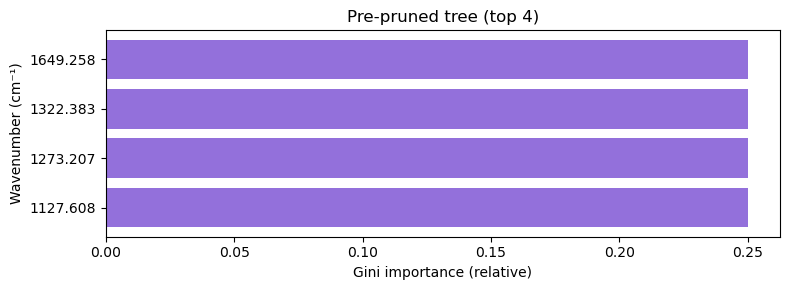

In [70]:
plot_topk_importances(model2, feature_names, top_k=25, title='Pre‑pruned tree')

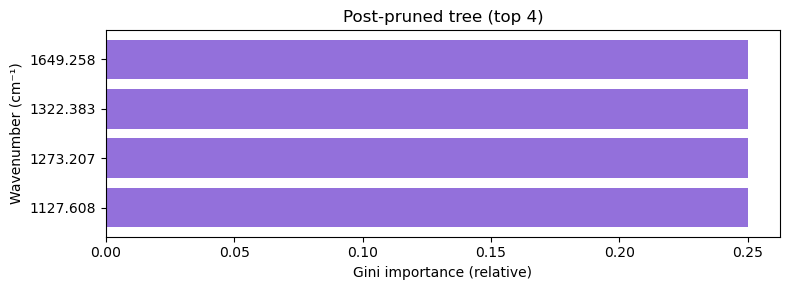

In [71]:
plot_topk_importances(model3, feature_names, top_k=25, title='Post‑pruned tree')